# Data Analysis

### Data Understanding

In [ ]:
resale = pd.read_csv("Data/processed.csv")
resale_extreme = resale[resale['floor_area_sqm'] > 350]  # drop the extreme outlier

summary = resale.groupby('flat_type').agg(
    Avg_Floor_Area=('floor_area_sqm', 'mean'),
    Avg_Resale_Price=('resale_price', 'mean'),
    Avg_Adjusted_Resale=('adjusted_resale', 'mean'),
    Count=('resale_price', 'count')
).round(2).sort_values('Avg_Floor_Area')

summary['Avg_Resale_Price'] = summary['Avg_Resale_Price'].apply(lambda x: f'${x:,.0f}')
summary['Avg_Adjusted_Resale'] = summary['Avg_Adjusted_Resale'].apply(lambda x: f'${x:,.0f}')
summary['Avg_Floor_Area'] = summary['Avg_Floor_Area'].apply(lambda x: f'{x:.1f} sqm')
display(summary)

,Avg_Floor_Area,Avg_Resale_Price,Avg_Adjusted_Resale,Count
flat_type,,,,
1 ROOM,31.0 sqm,"$211,987","$137,058",82
2 ROOM,45.7 sqm,"$301,466","$179,074",4586
3 ROOM,68.2 sqm,"$373,075","$233,229",53591
4 ROOM,95.0 sqm,"$530,607","$331,236",95464
5 ROOM,117.7 sqm,"$625,558","$395,549",55179
EXECUTIVE,144.8 sqm,"$733,328","$469,462",16140
MULTI-GENERATION,161.2 sqm,"$859,598","$576,238",85


In [ ]:
resale_extreme

,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,storey_type_lower,storey_type_middle,...,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count,nearest_mrt_dist,nearest_bus_stop_dist
182828,90,KALLANG/WHAMPOA,3 ROOM,366.7,564,1568000.0,1.328279,103.856097,True,False,...,192.9,812856.402281,0,0,0,12,0,0,1106,221


## Feature Heatmap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestRegressor
import warnings

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Load processed data
resale = pd.read_csv("Data/processed.csv")

print(resale.columns.tolist())

# Show first few rows
display(resale.head())

# Quick data info
print("\n" + "=" * 80)
print("DATA INFO")
print("=" * 80)
print(resale.info())

['month', 'town', 'flat_type', 'floor_area_sqm', 'remaining_lease', 'resale_price', 'latitude', 'longitude', 'storey_type_lower', 'storey_type_middle', 'storey_type_upper', 'rpi', 'adjusted_resale', 'mrt_count', 'school_count', 'mall_count', 'bus_stop_count', 'hawker_count', 'wet_market_count', 'nearest_mrt_dist', 'nearest_bus_stop_dist']


,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,storey_type_lower,storey_type_middle,...,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count,nearest_mrt_dist,nearest_bus_stop_dist
0,0,ANG MO KIO,2 ROOM,44.0,736,232000.0,1.362005,103.853880,False,False,...,133.9,173263.629574,0,3,0,14,1,0,1016,91
1,0,ANG MO KIO,3 ROOM,67.0,727,250000.0,1.370966,103.838202,True,False,...,133.9,186706.497386,1,2,0,11,1,0,202,164
2,0,ANG MO KIO,3 ROOM,67.0,749,262000.0,1.380709,103.835368,True,False,...,133.9,195668.409261,1,0,0,12,0,0,460,136
3,0,ANG MO KIO,3 ROOM,68.0,745,265000.0,1.366201,103.857201,False,True,...,133.9,197908.887229,0,1,0,10,2,0,828,68
4,0,ANG MO KIO,3 ROOM,67.0,749,265000.0,1.381041,103.835132,True,False,...,133.9,197908.887229,1,0,0,11,0,0,433,146



DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 225127 entries, 0 to 225126
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   month                  225127 non-null  int64  
 1   town                   225127 non-null  str    
 2   flat_type              225127 non-null  str    
 3   floor_area_sqm         225127 non-null  float64
 4   remaining_lease        225127 non-null  int64  
 5   resale_price           225127 non-null  float64
 6   latitude               225127 non-null  float64
 7   longitude              225127 non-null  float64
 8   storey_type_lower      225127 non-null  bool   
 9   storey_type_middle     225127 non-null  bool   
 10  storey_type_upper      225127 non-null  bool   
 11  rpi                    225127 non-null  float64
 12  adjusted_resale        225127 non-null  float64
 13  mrt_count              225127 non-null  int64  
 14  school_count           225127 non-nu

Analyzing 16 numeric features



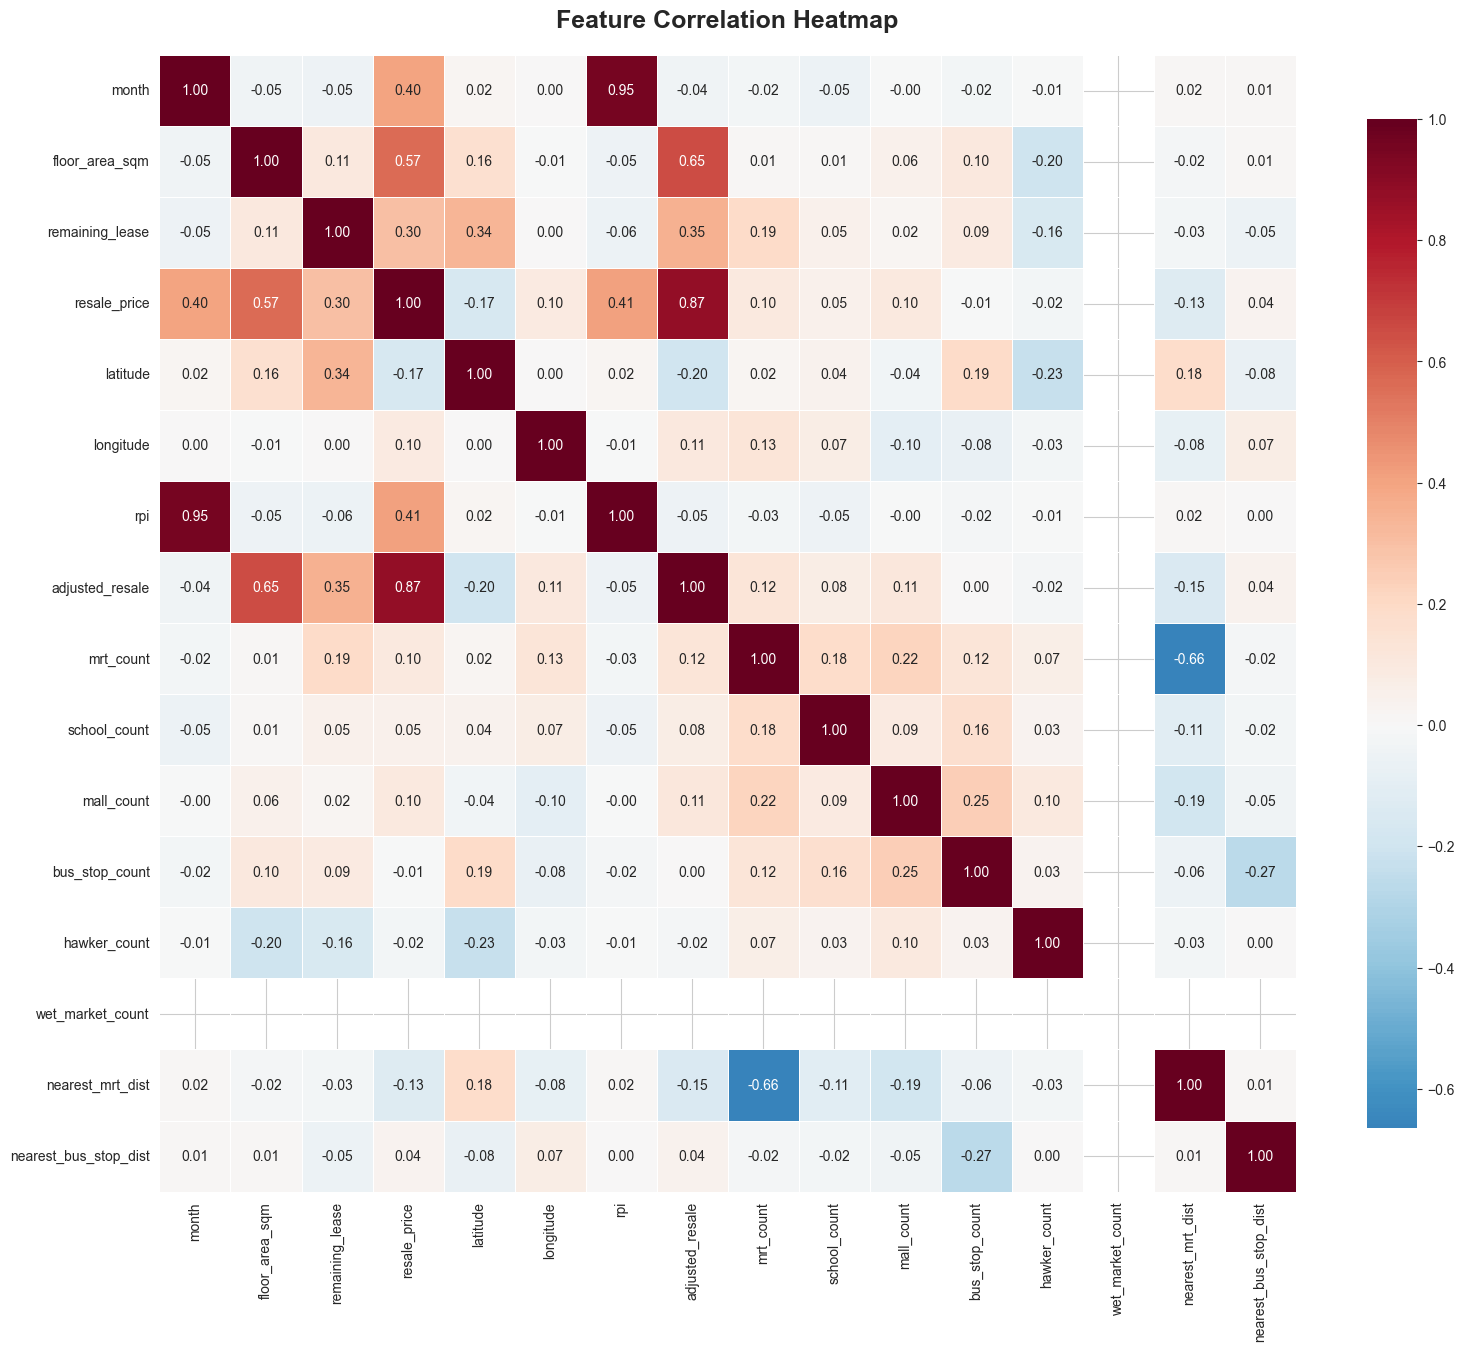

✓ Correlation heatmap generated


In [ ]:
# Get numeric columns only
numeric_cols = resale.select_dtypes(include=[np.number]).columns.tolist()
print(f"Analyzing {len(numeric_cols)} numeric features\n")

# Calculate correlation matrix
correlation_matrix = resale[numeric_cols].corr()

# Create correlation heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ Correlation heatmap generated")

## Feature Correlation observations (compared to adjusted resale)

## Outlier Analysis

In [ ]:
display(resale[numeric_cols].describe().round(2))

,month,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count,nearest_mrt_dist,nearest_bus_stop_dist
count,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,225127.0,225127.00,225127.00
mean,56.90,96.75,890.66,526253.70,1.37,103.84,159.68,330500.87,0.65,2.23,0.55,15.58,0.45,0.0,564.54,113.35
std,30.58,24.02,170.96,187445.06,0.04,0.07,26.50,107877.20,0.78,1.41,0.84,4.55,0.67,0.0,339.15,54.72
min,0.00,31.00,477.00,140000.00,1.27,103.69,130.80,83148.56,0.00,0.00,0.00,3.00,0.00,0.0,22.00,11.00
25%,31.00,81.00,749.00,388000.00,1.34,103.78,132.60,254365.98,0.00,1.00,0.00,12.00,0.00,0.0,316.00,73.00
50%,58.00,93.00,888.00,495000.00,1.37,103.85,155.70,312977.10,0.00,2.00,0.00,15.00,0.00,0.0,504.00,106.00
75%,83.00,112.00,1064.00,630000.00,1.40,103.90,180.40,385925.09,1.00,3.00,1.00,19.00,1.00,0.0,738.00,145.00
max,109.00,366.70,1173.00,1658888.00,1.46,103.99,203.70,939507.09,5.00,17.00,11.00,30.00,5.00,0.0,2596.00,393.00


### IQR outlier detection

In [ ]:
outlier_summary = []
for col in numeric_cols:
    Q1 = resale[col].quantile(0.25)
    Q3 = resale[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = resale[(resale[col] < lower) | (resale[col] > upper)]
    pct = len(outliers) / len(resale) * 100

    outlier_summary.append({
        'Feature': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round(pct, 2)
    })
outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,month,31.00,83.00,52.00,-47.00,161.00,0,0.00
1,floor_area_sqm,81.00,112.00,31.00,34.50,158.50,1203,0.53
2,remaining_lease,749.00,1064.00,315.00,276.50,1536.50,0,0.00
3,resale_price,388000.00,630000.00,242000.00,25000.00,993000.00,4328,1.92
4,latitude,1.34,1.40,0.06,1.25,1.49,0,0.00
5,longitude,103.78,103.90,0.12,103.60,104.08,0,0.00
6,rpi,132.60,180.40,47.80,60.90,252.10,0,0.00
7,adjusted_resale,254365.98,385925.09,131559.10,57027.33,583263.74,6455,2.87
8,mrt_count,0.00,1.00,1.00,-1.50,2.50,4590,2.04
9,school_count,1.00,3.00,2.00,-2.00,6.00,2517,1.12


In [ ]:
print("FEATURE ANALYSIS RESULTS & INTERPRETATION")
print("=" * 80)

# Define target variable
target_col = 'adjusted_resale' if 'adjusted_resale' in resale.columns else 'resale_price'

# Get correlations with target
numeric_cols = resale.select_dtypes(include=[np.number]).columns
target_correlations = resale[numeric_cols].corr()[target_col].sort_values(ascending=False)

# Categorize features by correlation strength and type
feature_categories = {
    'Strong Predictors (|r| > 0.5)': [],
    'Moderate Predictors (0.3 < |r| < 0.5)': [],
    'Physical Characteristics': [],
    'Location Features': [],
    'Amenity Features (Count)': [],
    'Amenity Features (Distance)': [],
    'Redundant Features (To Drop)': [],
    'Low Variance Features (To Drop)': []
}

# Categorize each feature
for feature, corr in target_correlations.items():
    if feature == target_col:
        continue

    abs_corr = abs(corr)

    # Check for redundancy
    if feature in ['resale_price', 'rpi']:
        feature_categories['Redundant Features (To Drop)'].append((feature, corr))
    elif feature == 'month':
        feature_categories['Low Variance Features (To Drop)'].append((feature, corr))
    elif feature == 'wet_market_count':
        feature_categories['Redundant Features (To Drop)'].append((feature, corr))

    # Strong predictors
    elif abs_corr > 0.5:
        feature_categories['Strong Predictors (|r| > 0.5)'].append((feature, corr))

    # Moderate predictors
    elif abs_corr >= 0.3:
        feature_categories['Moderate Predictors (0.3 < |r| < 0.5)'].append((feature, corr))

    # Physical characteristics
    elif feature in ['floor_area_sqm', 'remaining_lease', 'storey_type_lower', 'storey_type_middle',
                     'storey_type_upper']:
        feature_categories['Physical Characteristics'].append((feature, corr))

    # Location
    elif feature in ['latitude', 'longitude']:
        feature_categories['Location Features'].append((feature, corr))

    # Amenity counts
    elif 'count' in feature.lower():
        feature_categories['Amenity Features (Count)'].append((feature, corr))

    # Amenity distances
    elif 'dist' in feature.lower() or 'nearest' in feature.lower():
        feature_categories['Amenity Features (Distance)'].append((feature, corr))

# Display categorized features
print("\n" + "=" * 80)
print("FEATURES CATEGORIZED BY TYPE AND CORRELATION STRENGTH")
print("=" * 80)

for category, features in feature_categories.items():
    if features:
        print(f"\n{'─' * 80}")
        print(f"{category}:")
        print(f"{'─' * 80}")
        for feature, corr in features:
            print(f"  {feature:.<40} r = {corr:>6.3f}")

FEATURE ANALYSIS RESULTS & INTERPRETATION

FEATURES CATEGORIZED BY TYPE AND CORRELATION STRENGTH

────────────────────────────────────────────────────────────────────────────────
Strong Predictors (|r| > 0.5):
────────────────────────────────────────────────────────────────────────────────
  floor_area_sqm.......................... r =  0.650

────────────────────────────────────────────────────────────────────────────────
Moderate Predictors (0.3 < |r| < 0.5):
────────────────────────────────────────────────────────────────────────────────
  remaining_lease......................... r =  0.354

────────────────────────────────────────────────────────────────────────────────
Location Features:
────────────────────────────────────────────────────────────────────────────────
  longitude............................... r =  0.108
  latitude................................ r = -0.201

────────────────────────────────────────────────────────────────────────────────
Amenity Features (Count):
─

### Results Discussion

#### Columns to keep

##### Floor_area_sqm, Remaining_lease, latitude, Longitude, All amenities.

Floor_area_sqm and remaining_lease are the biggest impact based on the features and have been cross checked with experts in the field.

Lat,long itself might not seem like much but typically locations closer to the center of singapore would be priced higher, hence would be a factor

Although amenities itself has low correlation to the adjusted resale, they do have a real impact when asking experts in the field. It was suggested that the prices can vary by about 10% based on the amenities itself. While alone they might not amount to much together they might have a compounding effect which is why it is not wise to drop them.

#### Columns to drop

##### resale price, wet_market_count, rpi, month

resale price would be data leakage.
month is very similar to remaining lease, hence will be dropped, also because low correlation.
wet_market_count is too similar to hawker centers, unless we fix the 1:1 correlation, we drop one of them.
rpi is unnecessary for model training until the final multiplicative step.

## Scatterplot

## Feature Heatmap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestRegressor
import warnings

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Load processed data
resale = pd.read_csv("Data/processed.csv")

print(resale.columns.tolist())

# Show first few rows
display(resale.head())

# Quick data info
print("\n" + "=" * 80)
print("DATA INFO")
print("=" * 80)
print(resale.info())


['month', 'town', 'flat_type', 'floor_area_sqm', 'remaining_lease', 'resale_price', 'latitude', 'longitude', 'storey_type_lower', 'storey_type_middle', 'storey_type_upper', 'rpi', 'adjusted_resale', 'mrt_count', 'school_count', 'mall_count', 'bus_stop_count', 'hawker_count', 'wet_market_count', 'nearest_mrt_dist', 'nearest_bus_stop_dist']


,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,storey_type_lower,storey_type_middle,...,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count,nearest_mrt_dist,nearest_bus_stop_dist
0,0,ANG MO KIO,2 ROOM,44.0,736,232000.0,1.362005,103.853880,False,False,...,133.9,173263.629574,0,3,0,14,1,0,1016,91
1,0,ANG MO KIO,3 ROOM,67.0,727,250000.0,1.370966,103.838202,True,False,...,133.9,186706.497386,1,2,0,11,1,0,202,164
2,0,ANG MO KIO,3 ROOM,67.0,749,262000.0,1.380709,103.835368,True,False,...,133.9,195668.409261,1,0,0,12,0,0,460,136
3,0,ANG MO KIO,3 ROOM,68.0,745,265000.0,1.366201,103.857201,False,True,...,133.9,197908.887229,0,1,0,10,2,0,828,68
4,0,ANG MO KIO,3 ROOM,67.0,749,265000.0,1.381041,103.835132,True,False,...,133.9,197908.887229,1,0,0,11,0,0,433,146



DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 225127 entries, 0 to 225126
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   month                  225127 non-null  int64  
 1   town                   225127 non-null  str    
 2   flat_type              225127 non-null  str    
 3   floor_area_sqm         225127 non-null  float64
 4   remaining_lease        225127 non-null  int64  
 5   resale_price           225127 non-null  float64
 6   latitude               225127 non-null  float64
 7   longitude              225127 non-null  float64
 8   storey_type_lower      225127 non-null  bool   
 9   storey_type_middle     225127 non-null  bool   
 10  storey_type_upper      225127 non-null  bool   
 11  rpi                    225127 non-null  float64
 12  adjusted_resale        225127 non-null  float64
 13  mrt_count              225127 non-null  int64  
 14  school_count           225127 non-nu

Analyzing 16 numeric features



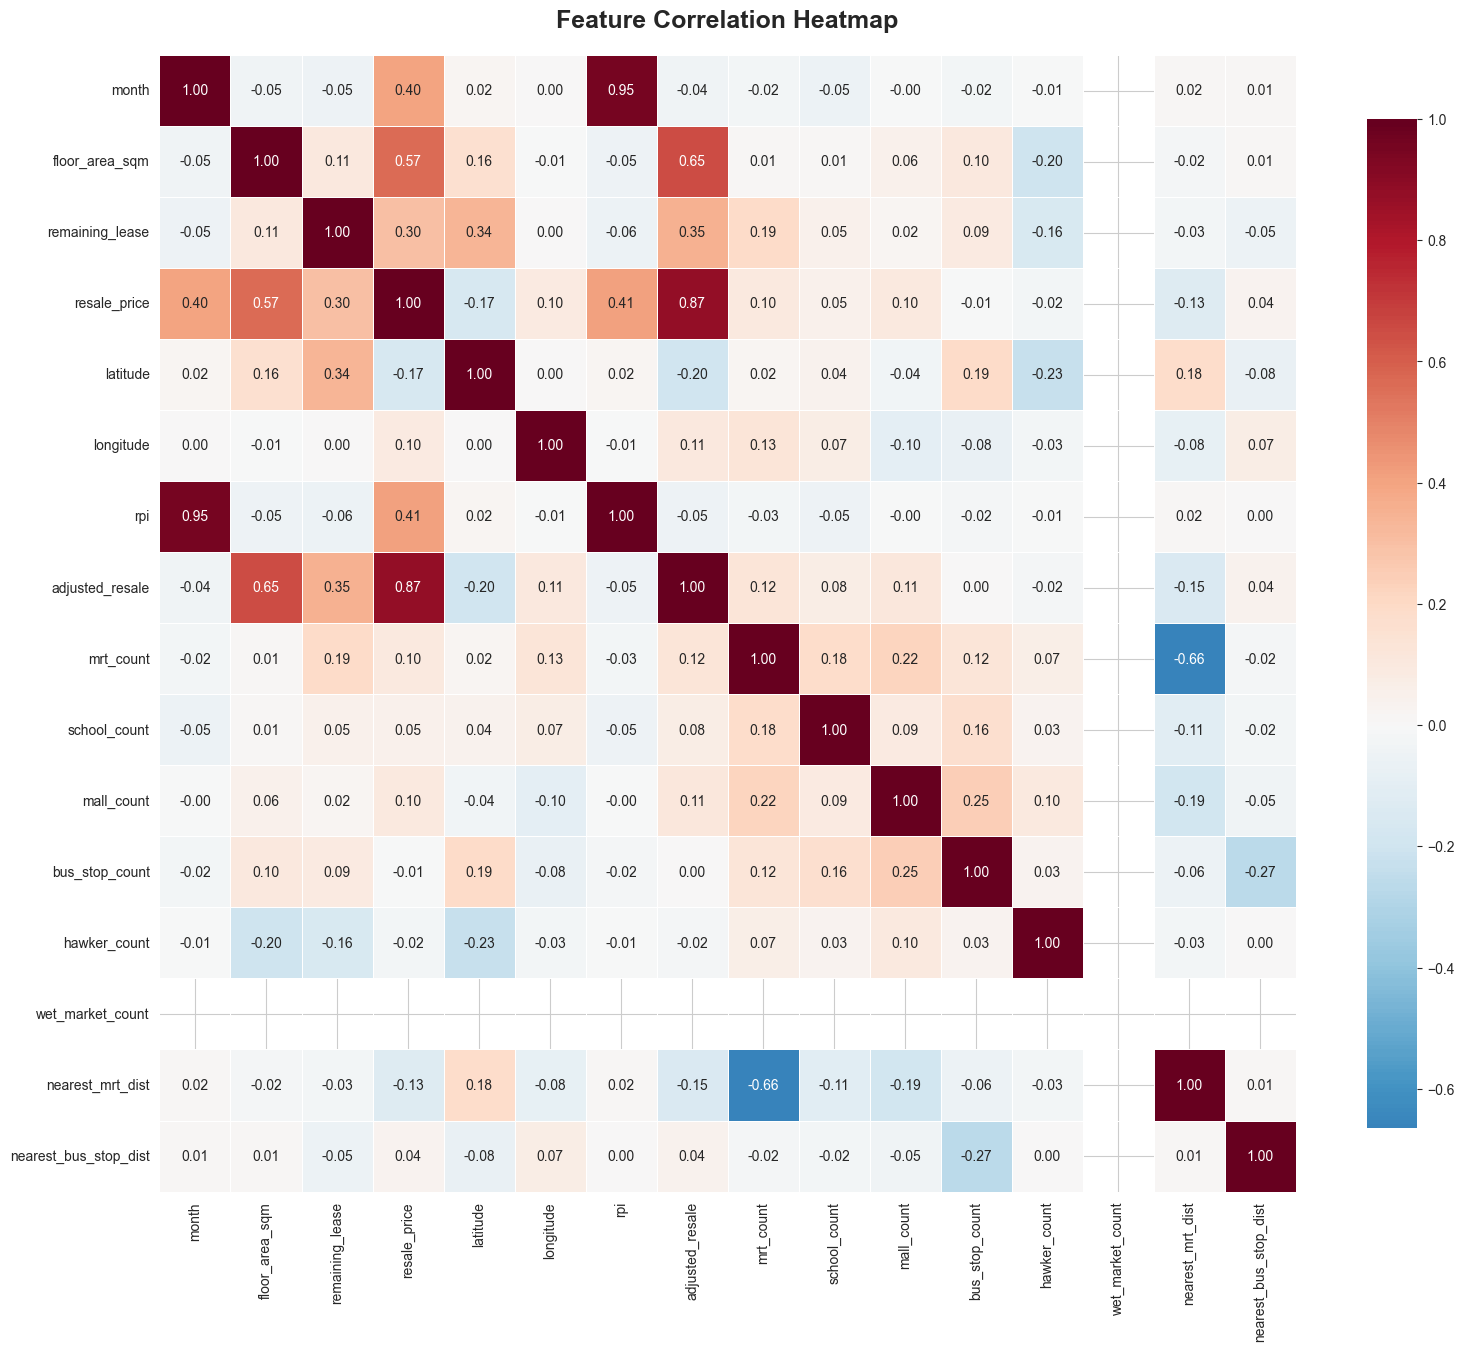

✓ Correlation heatmap generated


In [ ]:
# Get numeric columns only
numeric_cols = resale.select_dtypes(include=[np.number]).columns.tolist()
print(f"Analyzing {len(numeric_cols)} numeric features\n")

# Calculate correlation matrix
correlation_matrix = resale[numeric_cols].corr()

# Create correlation heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ Correlation heatmap generated")

## Feature Correlation observations (compared to adjusted resale)

## Outlier Analysis

## Scatterplot

OUTLIER COUNT BY FLAT TYPE


,Total,Outliers,Outlier %
flat_type,,,
1 ROOM,82,2,2.44
2 ROOM,4586,130,2.83
3 ROOM,53591,3355,6.26
4 ROOM,95464,7790,8.16
5 ROOM,55179,3287,5.96
EXECUTIVE,16140,469,2.91
MULTI-GENERATION,85,0,0.00



Total outliers: 15,033 / 225,127 (6.68%)


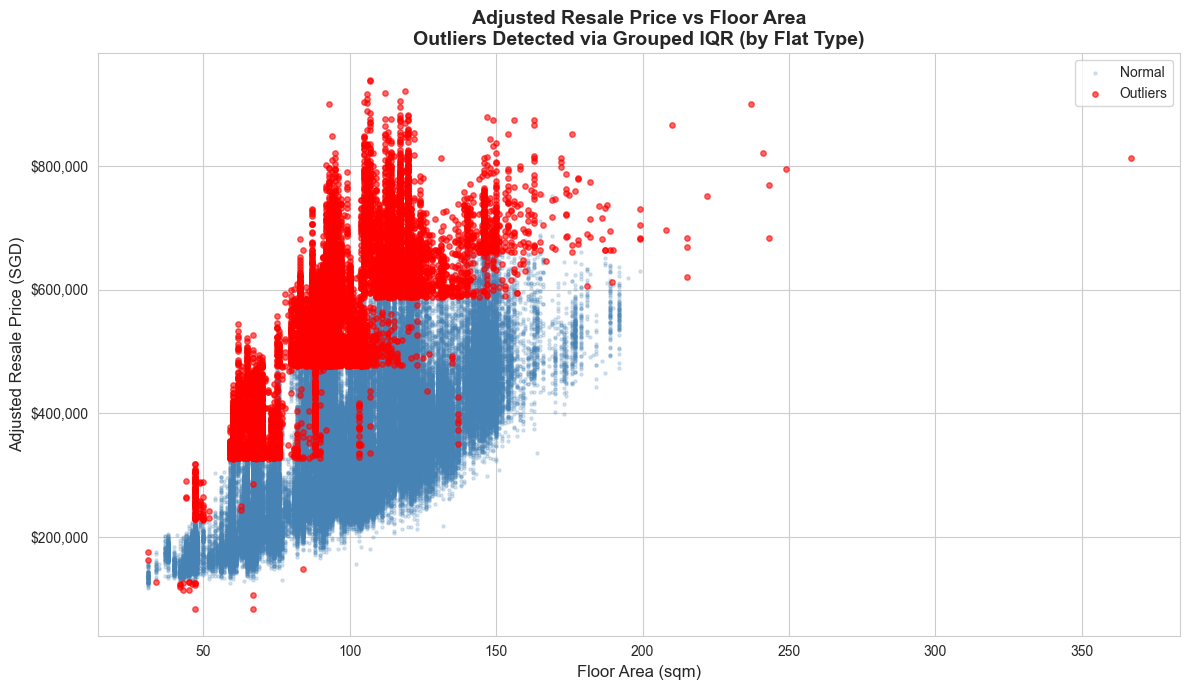

In [ ]:
# ------------------------------------------------------------
# IQR WITHIN GROUPS (by flat_type)
# ------------------------------------------------------------

plot_df = resale.dropna(subset=['adjusted_resale']).copy()


def flag_outliers_iqr(group, col, multiplier=1.5):
    Q1 = group[col].quantile(0.25)
    Q3 = group[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    return (group[col] < lower) | (group[col] > upper)


# Flag outliers within each flat_type group
plot_df['is_outlier'] = (
    plot_df.groupby('flat_type', group_keys=False)
    .apply(lambda g: flag_outliers_iqr(g, 'adjusted_resale'))
)

# Summary table
print("=" * 60)
print("OUTLIER COUNT BY FLAT TYPE")
print("=" * 60)
summary = plot_df.groupby('flat_type')['is_outlier'].agg(
    Total='count',
    Outliers='sum'
)
summary['Outlier %'] = (summary['Outliers'] / summary['Total'] * 100).round(2)
display(summary)

print(
    f"\nTotal outliers: {plot_df['is_outlier'].sum():,} / {len(plot_df):,} ({plot_df['is_outlier'].mean() * 100:.2f}%)")

# Scatter plot
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(plot_df.loc[~plot_df['is_outlier'], 'floor_area_sqm'],
           plot_df.loc[~plot_df['is_outlier'], 'adjusted_resale'],
           alpha=0.2, s=5, color='steelblue', label='Normal')

ax.scatter(plot_df.loc[plot_df['is_outlier'], 'floor_area_sqm'],
           plot_df.loc[plot_df['is_outlier'], 'adjusted_resale'],
           alpha=0.6, s=15, color='red', label='Outliers')

ax.set_xlabel('Floor Area (sqm)', fontsize=12)
ax.set_ylabel('Adjusted Resale Price (SGD)', fontsize=12)
ax.set_title('Adjusted Resale Price vs Floor Area\nOutliers Detected via Grouped IQR (by Flat Type)',
             fontsize=14, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

In [ ]:
display(resale[resale['floor_area_sqm'] >= 350])

,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,storey_type_lower,storey_type_middle,...,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count,nearest_mrt_dist,nearest_bus_stop_dist
182828,90,KALLANG/WHAMPOA,3 ROOM,366.7,564,1568000.0,1.328279,103.856097,True,False,...,192.9,812856.402281,0,0,0,12,0,0,1106,221


### Outlier discussion

We detect outliers by room types instead of one whole column because if we do by whole column, any price above a certain sqm will be flagged as outliers. For this graph we use interquartile range (25-75%) where anything above and below is outlier.
Here we can see it is more correct where certain extreme ends of data points are flagged out.
However, since these are actual datapoints. I suggest we only remove the extreme outliers. (E.g. from the graph above the one above 350 sqm)

In [ ]:
display(resale[numeric_cols].describe().round(2))

,month,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count,nearest_mrt_dist,nearest_bus_stop_dist
count,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,225127.0,225127.00,225127.00
mean,56.90,96.75,890.66,526253.70,1.37,103.84,159.68,330500.87,0.65,2.23,0.55,15.58,0.45,0.0,564.54,113.35
std,30.58,24.02,170.96,187445.06,0.04,0.07,26.50,107877.20,0.78,1.41,0.84,4.55,0.67,0.0,339.15,54.72
min,0.00,31.00,477.00,140000.00,1.27,103.69,130.80,83148.56,0.00,0.00,0.00,3.00,0.00,0.0,22.00,11.00
25%,31.00,81.00,749.00,388000.00,1.34,103.78,132.60,254365.98,0.00,1.00,0.00,12.00,0.00,0.0,316.00,73.00
50%,58.00,93.00,888.00,495000.00,1.37,103.85,155.70,312977.10,0.00,2.00,0.00,15.00,0.00,0.0,504.00,106.00
75%,83.00,112.00,1064.00,630000.00,1.40,103.90,180.40,385925.09,1.00,3.00,1.00,19.00,1.00,0.0,738.00,145.00
max,109.00,366.70,1173.00,1658888.00,1.46,103.99,203.70,939507.09,5.00,17.00,11.00,30.00,5.00,0.0,2596.00,393.00


### IQR outlier detection

In [ ]:
outlier_summary = []
for col in numeric_cols:
    Q1 = resale[col].quantile(0.25)
    Q3 = resale[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = resale[(resale[col] < lower) | (resale[col] > upper)]
    pct = len(outliers) / len(resale) * 100

    outlier_summary.append({
        'Feature': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round(pct, 2)
    })
outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,month,31.00,83.00,52.00,-47.00,161.00,0,0.00
1,floor_area_sqm,81.00,112.00,31.00,34.50,158.50,1203,0.53
2,remaining_lease,749.00,1064.00,315.00,276.50,1536.50,0,0.00
3,resale_price,388000.00,630000.00,242000.00,25000.00,993000.00,4328,1.92
4,latitude,1.34,1.40,0.06,1.25,1.49,0,0.00
5,longitude,103.78,103.90,0.12,103.60,104.08,0,0.00
6,rpi,132.60,180.40,47.80,60.90,252.10,0,0.00
7,adjusted_resale,254365.98,385925.09,131559.10,57027.33,583263.74,6455,2.87
8,mrt_count,0.00,1.00,1.00,-1.50,2.50,4590,2.04
9,school_count,1.00,3.00,2.00,-2.00,6.00,2517,1.12


In [ ]:
print("FEATURE ANALYSIS RESULTS & INTERPRETATION")
print("=" * 80)

# Define target variable
target_col = 'adjusted_resale' if 'adjusted_resale' in resale.columns else 'resale_price'

# Get correlations with target
numeric_cols = resale.select_dtypes(include=[np.number]).columns
target_correlations = resale[numeric_cols].corr()[target_col].sort_values(ascending=False)

# Categorize features by correlation strength and type
feature_categories = {
    'Strong Predictors (|r| > 0.5)': [],
    'Moderate Predictors (0.3 < |r| < 0.5)': [],
    'Physical Characteristics': [],
    'Location Features': [],
    'Amenity Features (Count)': [],
    'Amenity Features (Distance)': [],
    'Redundant Features (To Drop)': [],
    'Low Variance Features (To Drop)': []
}

# Categorize each feature
for feature, corr in target_correlations.items():
    if feature == target_col:
        continue

    abs_corr = abs(corr)

    # Check for redundancy
    if feature in ['resale_price', 'rpi']:
        feature_categories['Redundant Features (To Drop)'].append((feature, corr))
    elif feature == 'month':
        feature_categories['Low Variance Features (To Drop)'].append((feature, corr))
    elif feature == 'wet_market_count':
        feature_categories['Redundant Features (To Drop)'].append((feature, corr))

    # Strong predictors
    elif abs_corr > 0.5:
        feature_categories['Strong Predictors (|r| > 0.5)'].append((feature, corr))

    # Moderate predictors
    elif abs_corr >= 0.3:
        feature_categories['Moderate Predictors (0.3 < |r| < 0.5)'].append((feature, corr))

    # Physical characteristics
    elif feature in ['floor_area_sqm', 'remaining_lease', 'storey_type_lower', 'storey_type_middle',
                     'storey_type_upper']:
        feature_categories['Physical Characteristics'].append((feature, corr))

    # Location
    elif feature in ['latitude', 'longitude']:
        feature_categories['Location Features'].append((feature, corr))

    # Amenity counts
    elif 'count' in feature.lower():
        feature_categories['Amenity Features (Count)'].append((feature, corr))

    # Amenity distances
    elif 'dist' in feature.lower() or 'nearest' in feature.lower():
        feature_categories['Amenity Features (Distance)'].append((feature, corr))

# Display categorized features
print("\n" + "=" * 80)
print("FEATURES CATEGORIZED BY TYPE AND CORRELATION STRENGTH")
print("=" * 80)

for category, features in feature_categories.items():
    if features:
        print(f"\n{'─' * 80}")
        print(f"{category}:")
        print(f"{'─' * 80}")
        for feature, corr in features:
            print(f"  {feature:.<40} r = {corr:>6.3f}")

FEATURE ANALYSIS RESULTS & INTERPRETATION

FEATURES CATEGORIZED BY TYPE AND CORRELATION STRENGTH

────────────────────────────────────────────────────────────────────────────────
Strong Predictors (|r| > 0.5):
────────────────────────────────────────────────────────────────────────────────
  floor_area_sqm.......................... r =  0.650

────────────────────────────────────────────────────────────────────────────────
Moderate Predictors (0.3 < |r| < 0.5):
────────────────────────────────────────────────────────────────────────────────
  remaining_lease......................... r =  0.354

────────────────────────────────────────────────────────────────────────────────
Location Features:
────────────────────────────────────────────────────────────────────────────────
  longitude............................... r =  0.108
  latitude................................ r = -0.201

────────────────────────────────────────────────────────────────────────────────
Amenity Features (Count):
─

### Results Discussion

#### Columns to keep

##### Floor_area_sqm, Remaining_lease, latitude, Longitude, All amenities.

Floor_area_sqm and remaining_lease are the biggest impact based on the features and have been cross checked with experts in the field.

Lat,long itself might not seem like much but typically locations closer to the center of singapore would be priced higher, hence would be a factor

Although amenities itself has low correlation to the adjusted resale, they do have a real impact when asking experts in the field. It was suggested that the prices can vary by about 10% based on the amenities itself. While alone they might not amount to much together they might have a compounding effect which is why it is not wise to drop them.

#### Columns to drop

##### resale price, wet_market_count, rpi, month

resale price would be data leakage.
month is very similar to remaining lease, hence will be dropped, also because low correlation.
wet_market_count is too similar to hawker centers, unless we fix the 1:1 correlation, we drop one of them.
rpi is unnecessary for model training until the final multiplicative step.

OUTLIER COUNT BY FLAT TYPE


,Total,Outliers,Outlier %
flat_type,,,
1 ROOM,82,2,2.44
2 ROOM,4586,130,2.83
3 ROOM,53591,3355,6.26
4 ROOM,95464,7790,8.16
5 ROOM,55179,3287,5.96
EXECUTIVE,16140,469,2.91
MULTI-GENERATION,85,0,0.00



Total outliers: 15,033 / 225,127 (6.68%)


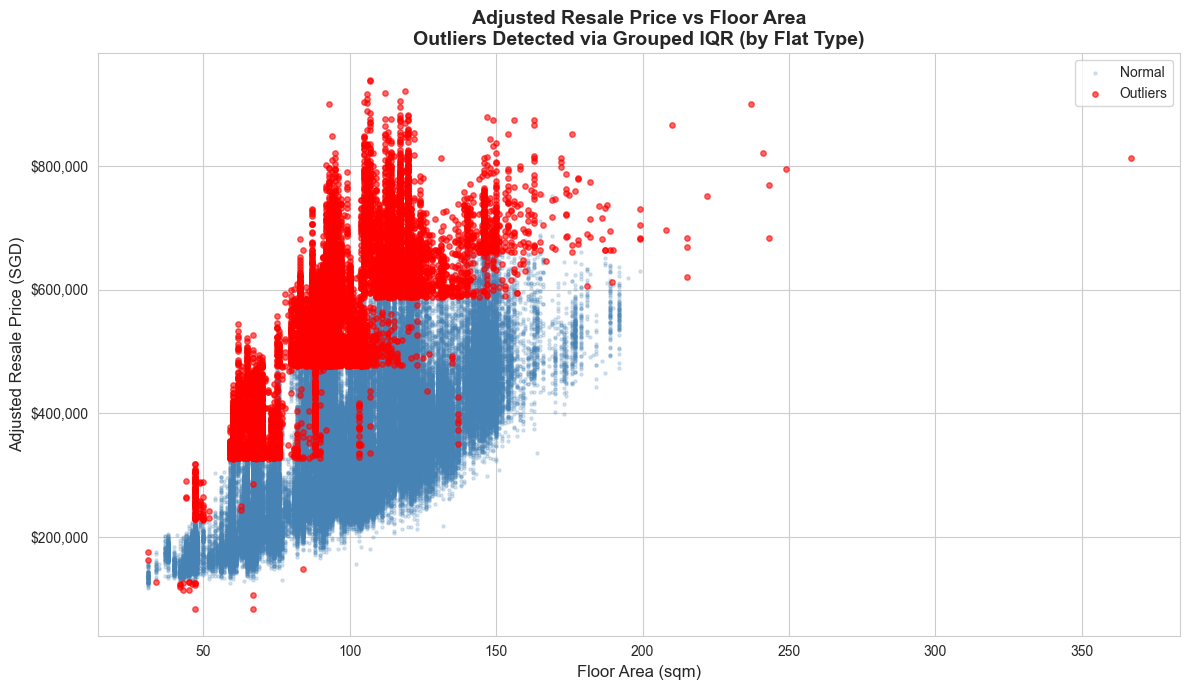

In [ ]:
# ------------------------------------------------------------
# IQR WITHIN GROUPS (by flat_type)
# ------------------------------------------------------------

plot_df = resale.dropna(subset=['adjusted_resale']).copy()


def flag_outliers_iqr(group, col, multiplier=1.5):
    Q1 = group[col].quantile(0.25)
    Q3 = group[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    return (group[col] < lower) | (group[col] > upper)


# Flag outliers within each flat_type group
plot_df['is_outlier'] = (
    plot_df.groupby('flat_type', group_keys=False)
    .apply(lambda g: flag_outliers_iqr(g, 'adjusted_resale'))
)

# Summary table
print("=" * 60)
print("OUTLIER COUNT BY FLAT TYPE")
print("=" * 60)
summary = plot_df.groupby('flat_type')['is_outlier'].agg(
    Total='count',
    Outliers='sum'
)
summary['Outlier %'] = (summary['Outliers'] / summary['Total'] * 100).round(2)
display(summary)

print(
    f"\nTotal outliers: {plot_df['is_outlier'].sum():,} / {len(plot_df):,} ({plot_df['is_outlier'].mean() * 100:.2f}%)")

# Scatter plot
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(plot_df.loc[~plot_df['is_outlier'], 'floor_area_sqm'],
           plot_df.loc[~plot_df['is_outlier'], 'adjusted_resale'],
           alpha=0.2, s=5, color='steelblue', label='Normal')

ax.scatter(plot_df.loc[plot_df['is_outlier'], 'floor_area_sqm'],
           plot_df.loc[plot_df['is_outlier'], 'adjusted_resale'],
           alpha=0.6, s=15, color='red', label='Outliers')

ax.set_xlabel('Floor Area (sqm)', fontsize=12)
ax.set_ylabel('Adjusted Resale Price (SGD)', fontsize=12)
ax.set_title('Adjusted Resale Price vs Floor Area\nOutliers Detected via Grouped IQR (by Flat Type)',
             fontsize=14, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

In [ ]:
display(resale[resale['floor_area_sqm'] >= 350])

,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,storey_type_lower,storey_type_middle,...,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count,nearest_mrt_dist,nearest_bus_stop_dist
182828,90,KALLANG/WHAMPOA,3 ROOM,366.7,564,1568000.0,1.328279,103.856097,True,False,...,192.9,812856.402281,0,0,0,12,0,0,1106,221


### Outlier discussion

We detect outliers by room types instead of one whole column because if we do by whole column, any price above a certain sqm will be flagged as outliers. For this graph we use interquartile range (25-75%) where anything above and below is outlier.
Here we can see it is more correct where certain extreme ends of data points are flagged out.
However, since these are actual datapoints. I suggest we only remove the extreme outliers. (E.g. from the graph above the one above 350 sqm)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestRegressor
import warnings

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Load processed data
resale = pd.read_csv("Data/processed.csv")

print(resale.columns.tolist())

# Show first few rows
display(resale.head())

# Quick data info
print("\n" + "=" * 80)
print("DATA INFO")
print("=" * 80)
print(resale.info())


['month', 'town', 'flat_type', 'floor_area_sqm', 'remaining_lease', 'resale_price', 'latitude', 'longitude', 'storey_type_lower', 'storey_type_middle', 'storey_type_upper', 'rpi', 'adjusted_resale', 'mrt_count', 'school_count', 'mall_count', 'bus_stop_count', 'hawker_count', 'wet_market_count', 'nearest_mrt_dist', 'nearest_bus_stop_dist']


,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,storey_type_lower,storey_type_middle,...,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count,nearest_mrt_dist,nearest_bus_stop_dist
0,0,ANG MO KIO,2 ROOM,44.0,736,232000.0,1.362005,103.853880,False,False,...,133.9,173263.629574,0,3,0,14,1,0,1016,91
1,0,ANG MO KIO,3 ROOM,67.0,727,250000.0,1.370966,103.838202,True,False,...,133.9,186706.497386,1,2,0,11,1,0,202,164
2,0,ANG MO KIO,3 ROOM,67.0,749,262000.0,1.380709,103.835368,True,False,...,133.9,195668.409261,1,0,0,12,0,0,460,136
3,0,ANG MO KIO,3 ROOM,68.0,745,265000.0,1.366201,103.857201,False,True,...,133.9,197908.887229,0,1,0,10,2,0,828,68
4,0,ANG MO KIO,3 ROOM,67.0,749,265000.0,1.381041,103.835132,True,False,...,133.9,197908.887229,1,0,0,11,0,0,433,146



DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 225127 entries, 0 to 225126
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   month                  225127 non-null  int64  
 1   town                   225127 non-null  str    
 2   flat_type              225127 non-null  str    
 3   floor_area_sqm         225127 non-null  float64
 4   remaining_lease        225127 non-null  int64  
 5   resale_price           225127 non-null  float64
 6   latitude               225127 non-null  float64
 7   longitude              225127 non-null  float64
 8   storey_type_lower      225127 non-null  bool   
 9   storey_type_middle     225127 non-null  bool   
 10  storey_type_upper      225127 non-null  bool   
 11  rpi                    225127 non-null  float64
 12  adjusted_resale        225127 non-null  float64
 13  mrt_count              225127 non-null  int64  
 14  school_count           225127 non-nu

Analyzing 16 numeric features



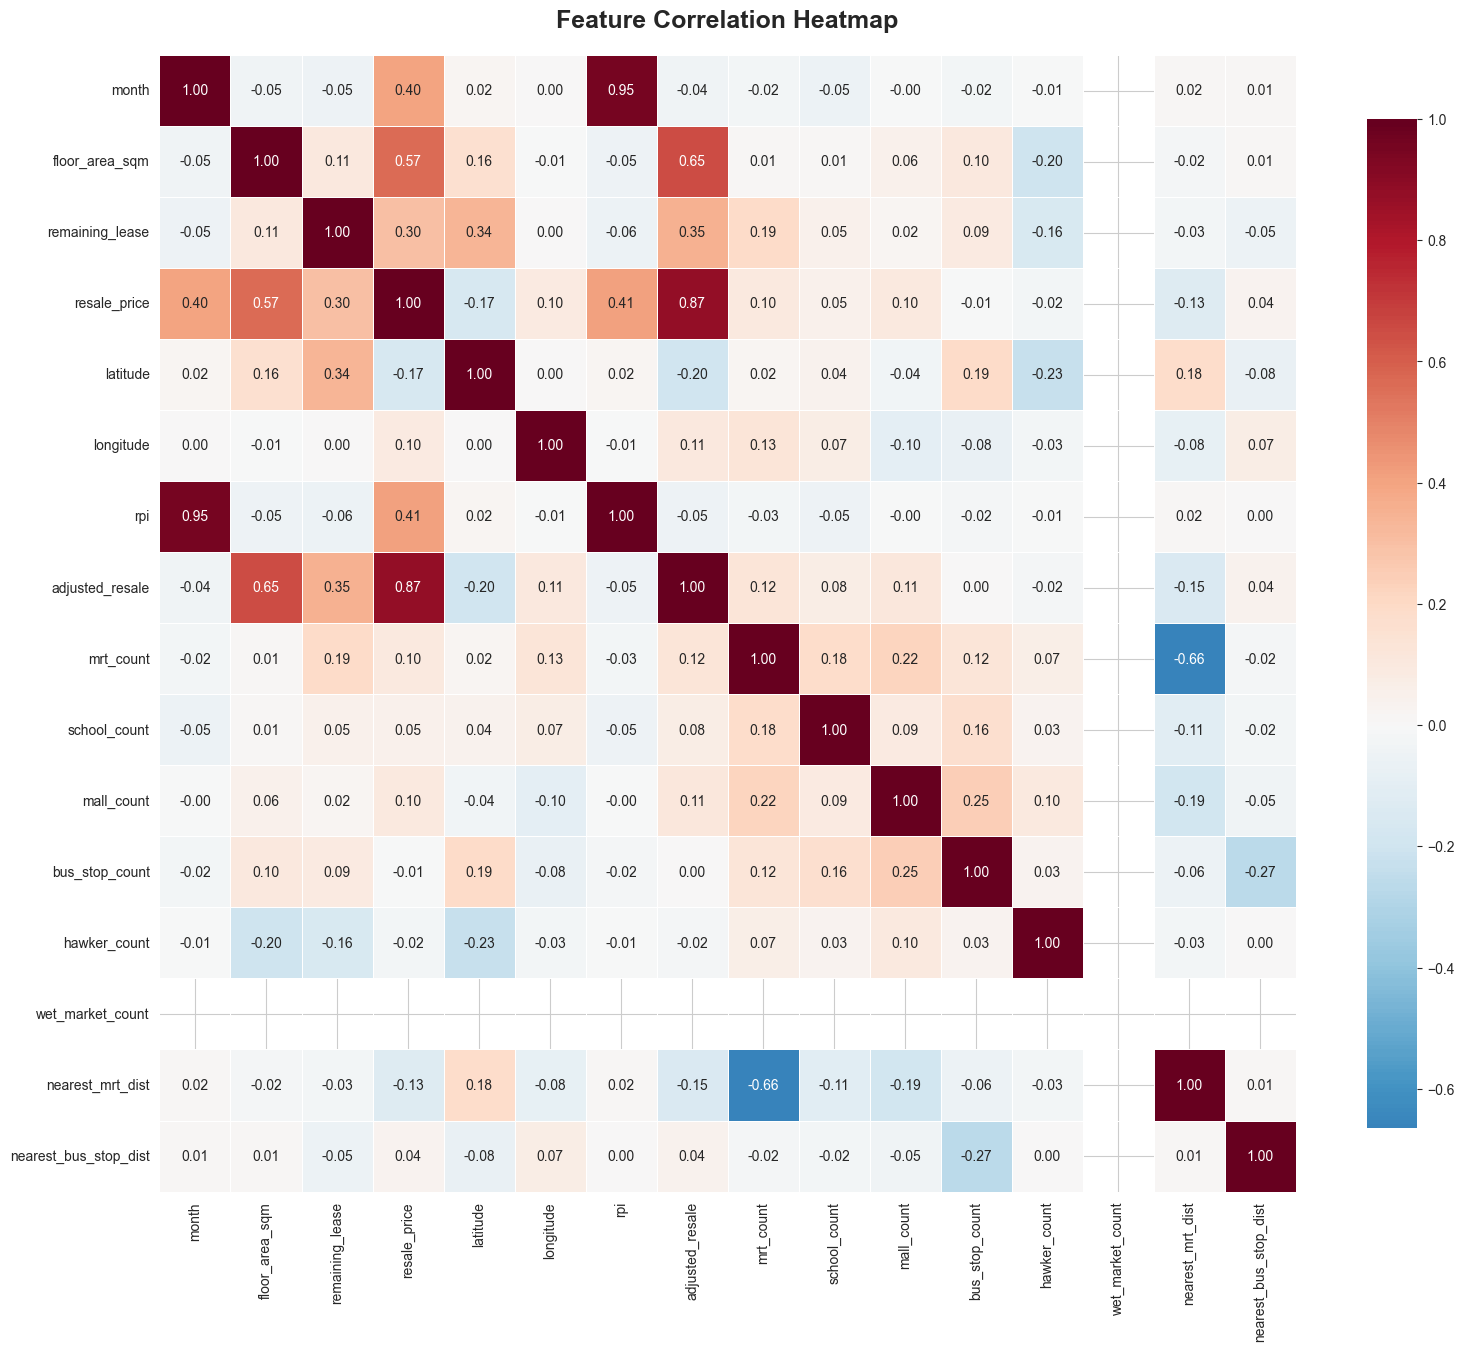

✓ Correlation heatmap generated


In [ ]:
# Get numeric columns only
numeric_cols = resale.select_dtypes(include=[np.number]).columns.tolist()
print(f"Analyzing {len(numeric_cols)} numeric features\n")

# Calculate correlation matrix
correlation_matrix = resale[numeric_cols].corr()

# Create correlation heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ Correlation heatmap generated")

#### 1. Fix missing RPI for months 108 & 109

In [ ]:
resale.loc[resale['month'].isin([108, 109]), 'rpi'] = 203.4
resale.loc[resale['month'].isin([108, 109]), 'adjusted_resale'] = (
    resale.loc[resale['month'].isin([108, 109]), 'resale_price'] / 203.4 * 100
)
print(f"After RPI fix - Nulls remaining: {resale.isnull().sum().sum()}")

After RPI fix - Nulls remaining: 0


#### 2. Drop duplicates

In [ ]:
before = len(resale)
resale = resale.drop_duplicates()
print(f"Dropped {before - len(resale)} duplicate rows → {len(resale)} rows remaining")

Dropped 505 duplicate rows → 224622 rows remaining


#### 3. Remove anomalous 366.7 sqm 3-room flat

In [ ]:
before = len(resale)
resale = resale[~((resale['flat_type'] == '3 ROOM') & (resale['floor_area_sqm'] > 300))]
print(f"Dropped {before - len(resale)} anomalous oversized 3-room flat → {len(resale)} rows remaining")

Dropped 1 anomalous oversized 3-room flat → 224621 rows remaining


#### 4. Remove jumbo 3-room flats (legacy 70s-80s flats)

In [ ]:
before = len(resale)
resale = resale[~(
    (resale['flat_type'] == '3 ROOM') &
    (resale['floor_area_sqm'] > 100) &
    (resale['town'].isin(['KALLANG/WHAMPOA', 'CENTRAL AREA', 'TOA PAYOH']))
)]
print(f"Dropped {before - len(resale)} jumbo 3-room flats → {len(resale)} rows remaining")

Dropped 79 jumbo 3-room flats → 224542 rows remaining


# Export Data

In [ ]:
resale.to_csv('Data/processed.csv', index=False)